# NeRF — Visual Experiments (a 2D differentiable renderer)

> **Goal:** Build NeRF's machinery end-to-end at a scale that runs in minutes. NeRF in 3D is heavy, so we use a faithful **2D analogue**: a scene is a field $(x,y)\mapsto(\sigma,\text{rgb})$, "cameras" are 1D parallel-beam sensors around it, and a pixel is formed by **volume rendering** (alpha compositing) along a ray. Every core idea survives — differentiable rendering, learning a field from *only* multi-view 2D supervision, novel-view synthesis, and positional encoding.

## What we'll explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **Alpha compositing on one ray** | How does the volume-rendering integral turn density+color into one pixel? |
| 2 | **A scene and its multi-view captures** | What does the differentiable renderer produce as training data? |
| 3 | **Learn the field from 2D views** | Can an MLP recover the 3D(2D) field from only rendered views? |
| 4 | **Novel-view synthesis** | Does the trained field render a *held-out* camera angle correctly? |
| 5 | **Positional encoding ablation** | Why does NeRF need positional encoding? |

---
**Linked theory:** [research/02-nerf.md](../research/02-nerf.md)  ·  **Chạy:** `uv run jupyter lab` từ thư mục `latent-anything-theory/` (cần các package trong `pyproject.toml`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})
print('Setup complete. torch', torch.__version__)

Setup complete. torch 2.12.0+cpu


---
## A shared toolkit: scene field, rays, and the volume renderer

Three pieces, defined once.

- **Ground-truth scene** — an analytic field returning density $\sigma$ and colour for any point; here three coloured disks on a white background.
- **Parallel-beam rays** — a camera at angle $\varphi$ shoots a fan of parallel rays across the scene; each ray is sampled at $S$ points.
- **Volume renderer** — the discrete NeRF compositing rule
  $\hat C=\sum_i T_i\,(1-e^{-\sigma_i\delta_i})\,c_i$ with $T_i=\exp(-\sum_{j<i}\sigma_j\delta_j)$.
  It is differentiable, so gradients flow from rendered pixels back to the field.

In [2]:
# --- ground-truth scene: three coloured disks (density + rgb) ---
DISKS = [((-0.35, 0.05), 0.28, (0.85, 0.20, 0.20)),   # red
         ((0.32, 0.20), 0.22, (0.20, 0.65, 0.25)),    # green
         ((0.05, -0.38), 0.20, (0.25, 0.40, 0.85))]   # blue
SIGMA_MAX = 40.0

def gt_field(pts):
    """pts: (...,2) float32 -> sigma (...,), rgb (...,3). Hard disk membership."""
    sigma = torch.zeros(pts.shape[:-1])
    rgb = torch.zeros(pts.shape[:-1] + (3,))
    filled = torch.zeros(pts.shape[:-1], dtype=torch.bool)
    for (cx, cy), r, col in DISKS:
        inside = ((pts[..., 0] - cx) ** 2 + (pts[..., 1] - cy) ** 2) < r ** 2
        take = inside & (~filled)                 # first disk wins on overlap
        sigma = torch.where(inside, torch.tensor(SIGMA_MAX), sigma)
        for k in range(3):
            rgb[..., k] = torch.where(take, torch.tensor(col[k]), rgb[..., k])
        filled = filled | inside
    return sigma, rgb

# --- parallel-beam camera at angle phi (everything kept float32) ---
def make_rays(phi, n_pix=72, n_samp=96, half=1.45):
    u = torch.tensor([np.cos(phi), np.sin(phi)], dtype=torch.float32)    # ray direction
    v = torch.tensor([-np.sin(phi), np.cos(phi)], dtype=torch.float32)   # sensor (lateral) axis
    s = torch.linspace(-1.1, 1.1, n_pix)                  # pixel offsets
    t = torch.linspace(-half, half, n_samp)               # along-ray samples
    pts = s[:, None, None] * v + t[None, :, None] * u     # (n_pix, n_samp, 2)
    delta = (t[1] - t[0]).item()
    return pts, delta

# --- differentiable volume rendering (NeRF compositing) ---
def render(field_fn, pts, delta, white_bg=True):
    flat = pts.reshape(-1, 2)
    sigma, rgb = field_fn(flat)
    sigma = sigma.reshape(pts.shape[:-1])                 # (n_pix, n_samp)
    rgb = rgb.reshape(pts.shape[:-1] + (3,))
    alpha = 1.0 - torch.exp(-sigma * delta)               # opacity per sample
    ones = torch.ones_like(alpha[:, :1])
    T = torch.cumprod(torch.cat([ones, 1.0 - alpha + 1e-10], dim=1), dim=1)[:, :-1]
    w = T * alpha                                         # contribution weight
    C = (w[..., None] * rgb).sum(dim=1)                   # (n_pix, 3)
    if white_bg:
        C = C + (1.0 - w.sum(dim=1, keepdim=True)) * 1.0
    return C, w

# sanity check: render the GT scene from one angle
pts0, d0 = make_rays(0.0)
C0, _ = render(gt_field, pts0, d0)
print('rendered 1D view shape:', tuple(C0.shape), ' (pixels x rgb)')

rendered 1D view shape: (72, 3)  (pixels x rgb)


---
## Experiment 1: Alpha compositing on a single ray

**Question:** The heart of NeRF is the volume-rendering integral — given density $\sigma(t)$ and colour $c(t)$ along a ray, it produces one pixel colour. How do the **transmittance** $T_i$ and the **weights** $w_i = T_i(1-e^{-\sigma_i\delta_i})$ decide *which* point along the ray a pixel actually "sees"?

We hand-craft a density profile along one ray — empty space, then a sharp opaque surface, then a second surface behind it — and watch the compositing weights.

In [3]:
np.random.seed(1)
t = torch.linspace(0, 1, 200)
delta = (t[1] - t[0]).item()

# density: two opaque surfaces (a front one at 0.35, a back one at 0.7)
sigma = (60 * torch.exp(-((t - 0.35) / 0.03) ** 2)
         + 60 * torch.exp(-((t - 0.70) / 0.03) ** 2))
alpha = 1 - torch.exp(-sigma * delta)
ones = torch.ones_like(alpha[:1])
T = torch.cumprod(torch.cat([ones, 1 - alpha + 1e-10]), 0)[:-1]
w = T * alpha

print(f'peak weight at front surface (t=0.35): {w[t.sub(0.35).abs().argmin()]:.3f}')
print(f'peak weight at back surface  (t=0.70): {w[t.sub(0.70).abs().argmin()]:.3f}')
print(f'transmittance reaching the back surface: {T[t.sub(0.70).abs().argmin()]:.3f}  (front surface absorbed most of it)')

peak weight at front surface (t=0.35): 0.055
peak weight at back surface  (t=0.70): 0.003
transmittance reaching the back surface: 0.011  (front surface absorbed most of it)


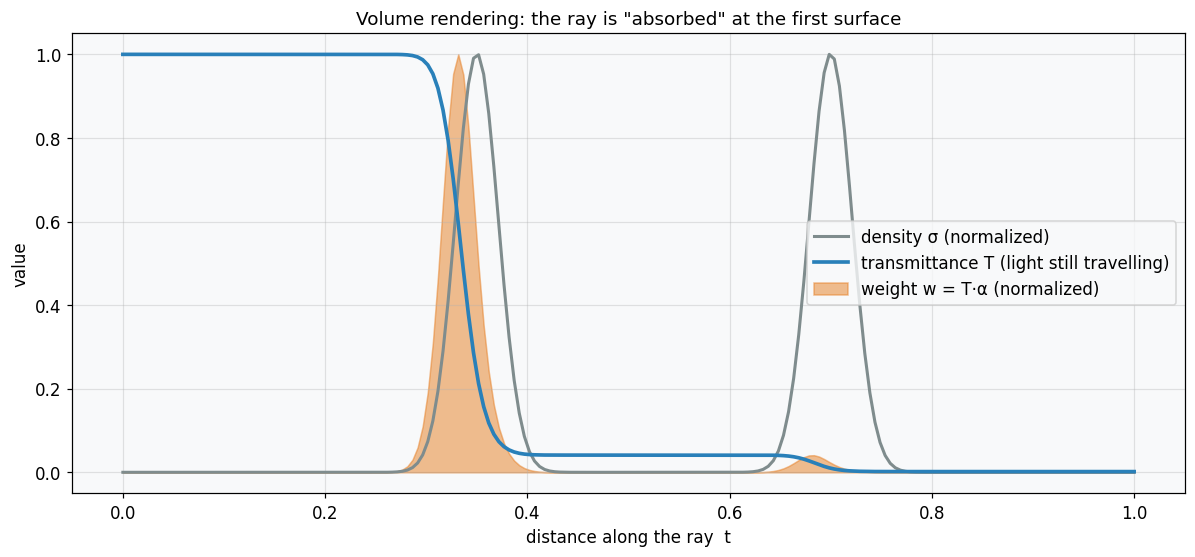

In [4]:
fig, ax = plt.subplots(figsize=(11, 5.2))
tn = t.numpy()
ax.plot(tn, sigma.numpy() / sigma.max().item(), color='#7f8c8d', lw=2, label='density σ (normalized)')
ax.plot(tn, T.numpy(), color='#2980b9', lw=2.4, label='transmittance T (light still travelling)')
ax.fill_between(tn, w.numpy() / w.max().item(), color='#e67e22', alpha=0.5, label='weight w = T·α (normalized)')
ax.set_xlabel('distance along the ray  t')
ax.set_ylabel('value')
ax.set_title('Volume rendering: the ray is "absorbed" at the first surface')
ax.legend()
plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Two density bumps sit along the ray. The transmittance $T$ (blue) starts at 1 and **drops to near zero right after the first surface**. The weight $w=T\alpha$ (orange) spikes at the *front* surface and is almost nonexistent at the back one, even though the back surface is equally dense.

2. **Why it looks this way:** $T_i$ is the fraction of light that survived everything before sample $i$; once the front surface absorbs it, little is left to reach the back. The weight $w_i$ — how much sample $i$ contributes to the pixel — is high only where the medium is *both* dense ($\alpha$ large) *and* not yet occluded ($T$ large). That product is exactly occlusion-aware rendering.

3. **Key takeaway:** The compositing rule makes a pixel see the *first* opaque thing along its ray — and because every step is a smooth function of $\sigma$ and $c$, the whole renderer is differentiable. That differentiability is what lets NeRF learn a field from images alone.

---
## Experiment 2: A scene and its multi-view captures

**Question:** NeRF's only training data is a set of images taken from known camera poses. What does that look like here — the 2D scene, and the 1D "photos" our renderer produces from several angles?

We rasterize the ground-truth field to a 2D image (for our eyes only) and render it from 8 camera angles to build the training set.

In [5]:
# rasterize GT scene to an image (visualization only)
gx, gy = torch.meshgrid(torch.linspace(-1, 1, 200), torch.linspace(-1, 1, 200), indexing='xy')
grid = torch.stack([gx, gy], dim=-1)
with torch.no_grad():
    sig_img, rgb_img = gt_field(grid)
scene_img = torch.where(sig_img[..., None] > 0, rgb_img, torch.ones_like(rgb_img)).numpy()

# build training captures from 8 angles in [0, pi)
train_angles = np.linspace(0, np.pi, 8, endpoint=False)
captures = []
with torch.no_grad():
    for phi in train_angles:
        pts, delta = make_rays(phi)
        C, _ = render(gt_field, pts, delta)
        captures.append((pts, delta, C))
views = np.stack([c[2].numpy() for c in captures])   # (8, n_pix, 3)
print(f'{len(captures)} training views, each {views.shape[1]} pixels')

8 training views, each 72 pixels


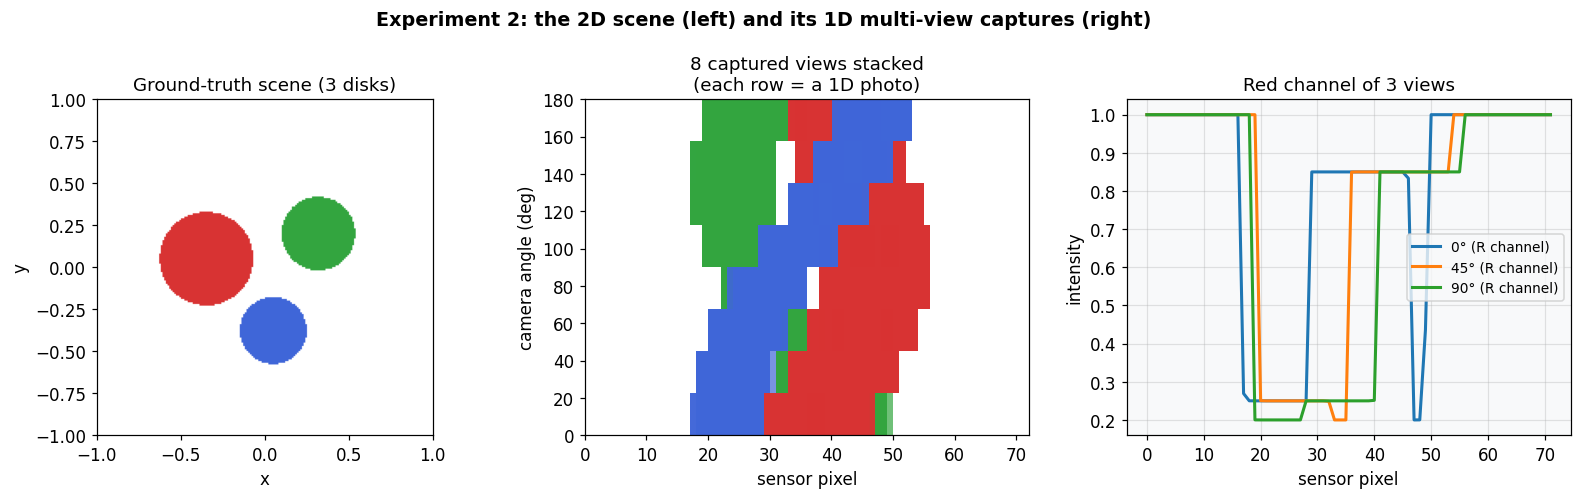

In [6]:
fig = plt.figure(figsize=(15, 4.6))
fig.suptitle('Experiment 2: the 2D scene (left) and its 1D multi-view captures (right)',
             fontsize=12.5, fontweight='bold')

ax = fig.add_subplot(1, 3, 1)
ax.imshow(scene_img, extent=[-1, 1, -1, 1], origin='lower')
ax.set_title('Ground-truth scene (3 disks)'); ax.set_xlabel('x'); ax.set_ylabel('y'); ax.grid(False)

ax2 = fig.add_subplot(1, 3, 2)
ax2.imshow(views, aspect='auto', origin='lower', extent=[0, views.shape[1], 0, 180])
ax2.set_title('8 captured views stacked\n(each row = a 1D photo)')
ax2.set_xlabel('sensor pixel'); ax2.set_ylabel('camera angle (deg)'); ax2.grid(False)

ax3 = fig.add_subplot(1, 3, 3)
for k in [0, 2, 4]:
    ax3.plot(views[k, :, 0], lw=2, label=f'{np.degrees(train_angles[k]):.0f}° (R channel)')
ax3.set_title('Red channel of 3 views'); ax3.set_xlabel('sensor pixel'); ax3.set_ylabel('intensity')
ax3.legend(fontsize=9)
plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Left is the true scene the network will *never* see directly. Middle stacks the 8 one-dimensional renders — each row is what one camera records. Right overlays the red channel from three angles: the red disk shows up at different sensor positions depending on the viewing angle.

2. **Why it looks this way:** Each capture is the volume-rendering integral applied to every ray of that camera. A disk projects to a coloured band whose position and width shift with the angle — this *parallax* across views is the only signal that encodes where things are in 2D.

3. **Key takeaway:** This is exactly NeRF's input contract: posed 2D images, nothing more. The 3D (here 2D) structure is implicit in the cross-view consistency, and the renderer is the bridge that will let gradients turn these captures back into a field.

---
## Experiment 3: Learn the field from 2D views only

**Question:** Now the real NeRF step. Can a coordinate MLP $F_\Theta(x,y)\to(\sigma,\text{rgb})$, trained *only* to re-render the 8 captured views (photometric loss), recover the underlying field — the disks it was never shown directly?

We fit a Fourier-feature MLP by minimizing the squared error between its renders and the captures, then read its field on a dense grid.

In [7]:
torch.manual_seed(3)

class RadianceField(nn.Module):
    """(x,y) -> (sigma, rgb). Optional Fourier-feature positional encoding."""
    def __init__(self, hidden=128, n_freq=8, use_pe=True):
        super().__init__()
        self.use_pe = use_pe
        self.freqs = 2.0 ** torch.arange(n_freq) * np.pi
        in_dim = 2 + 2 * 2 * n_freq if use_pe else 2
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 4),
        )

    def encode(self, p):
        if not self.use_pe:
            return p
        ang = p[..., None] * self.freqs            # (...,2,n_freq)
        enc = torch.cat([torch.sin(ang), torch.cos(ang)], dim=-1).reshape(*p.shape[:-1], -1)
        return torch.cat([p, enc], dim=-1)

    def forward(self, p):
        out = self.net(self.encode(p))
        sigma = F.softplus(out[..., 0])            # density >= 0
        rgb = torch.sigmoid(out[..., 1:4])         # colour in [0,1]
        return sigma, rgb

def train_field(field, steps=1200, lr=3e-3, seed=0):
    torch.manual_seed(seed)
    opt = torch.optim.Adam(field.parameters(), lr=lr)
    losses = []
    for _ in range(steps):
        opt.zero_grad()
        loss = 0.0
        for pts, delta, C_gt in captures:
            C, _ = render(field.forward, pts, delta)
            loss = loss + F.mse_loss(C, C_gt)
        loss = loss / len(captures)
        loss.backward(); opt.step()
        losses.append(loss.item())
    return losses

field = RadianceField(use_pe=True)
losses = train_field(field, steps=1200, seed=3)
with torch.no_grad():
    sig_pred, rgb_pred = field(grid)
    recovered = torch.where(sig_pred[..., None] > 1.0, rgb_pred, torch.ones_like(rgb_pred)).numpy()
print(f'final photometric loss: {losses[-1]:.2e}')

final photometric loss: 2.48e-06


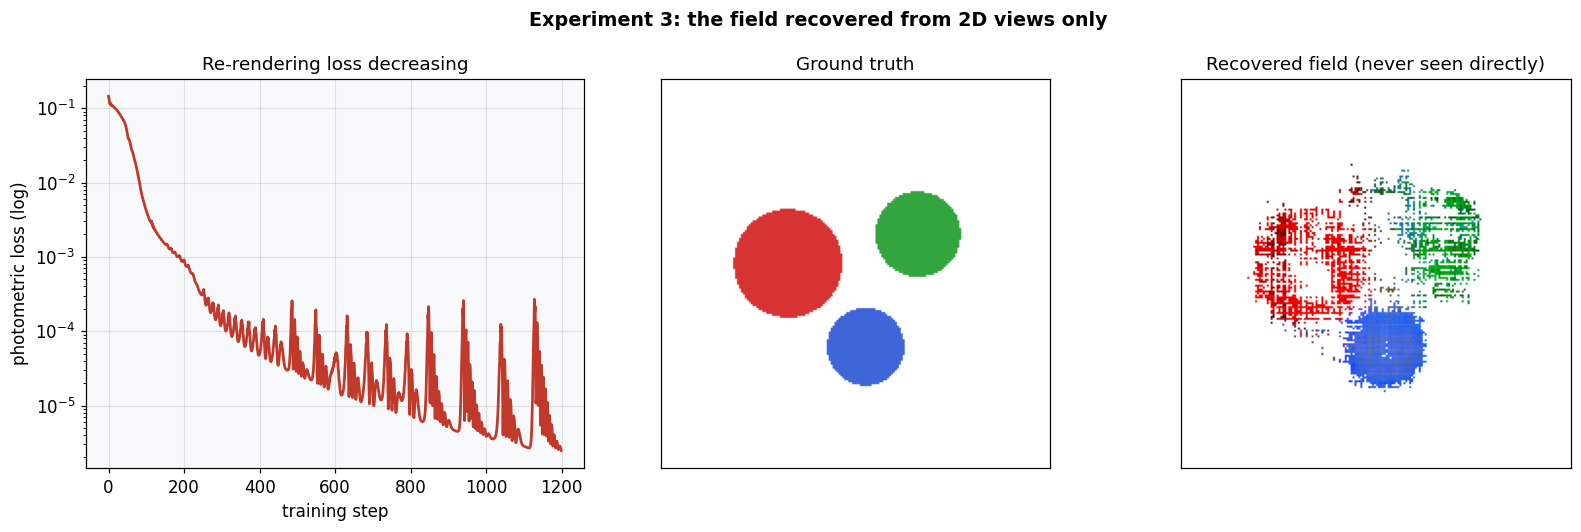

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.9))
fig.suptitle('Experiment 3: the field recovered from 2D views only',
             fontsize=12.5, fontweight='bold')

axes[0].plot(losses, color='#c0392b', lw=1.8); axes[0].set_yscale('log')
axes[0].set_xlabel('training step'); axes[0].set_ylabel('photometric loss (log)')
axes[0].set_title('Re-rendering loss decreasing')

axes[1].imshow(scene_img, extent=[-1, 1, -1, 1], origin='lower')
axes[1].set_title('Ground truth'); axes[1].set_xticks([]); axes[1].set_yticks([]); axes[1].grid(False)

axes[2].imshow(np.clip(recovered, 0, 1), extent=[-1, 1, -1, 1], origin='lower')
axes[2].set_title('Recovered field (never seen directly)'); axes[2].set_xticks([]); axes[2].set_yticks([]); axes[2].grid(False)
plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The photometric loss falls steadily, and the field read off the trained MLP (right) reproduces the three coloured disks of the ground truth (middle) — their positions, sizes, and colours — despite the network only ever being trained to match 1D renders.

2. **Why it looks this way:** Back-propagating the re-rendering error through the differentiable volume renderer pushes the MLP to place density and colour wherever they are needed to explain *all* views simultaneously. A wrong field would satisfy one view but break another; only the true geometry is consistent across angles, so gradient descent converges to it.

3. **Key takeaway:** This is NeRF in miniature: **3D structure emerges from 2D supervision** because the renderer is differentiable and multi-view consistency pins down the field. No 3D labels, meshes, or depth were used.

---
## Experiment 4: Novel-view synthesis

**Question:** The whole point of NeRF is rendering *new* viewpoints. Does the trained field render a camera angle that was **not** in the training set, and does it match the ground truth from that angle?

We pick a held-out angle between two training angles and render it from both the trained field and the true scene.

In [9]:
novel_phi = np.pi / 8 + np.pi / 16          # a held-out angle (between training angles)
pts_n, delta_n = make_rays(novel_phi)
with torch.no_grad():
    C_gt_novel, _ = render(gt_field, pts_n, delta_n)
    C_pred_novel, _ = render(field.forward, pts_n, delta_n)
err = F.mse_loss(C_pred_novel, C_gt_novel).item()
print(f'held-out angle: {np.degrees(novel_phi):.1f} deg (not in training set)')
print(f'novel-view render MSE: {err:.2e}')

held-out angle: 33.8 deg (not in training set)
novel-view render MSE: 5.57e-03


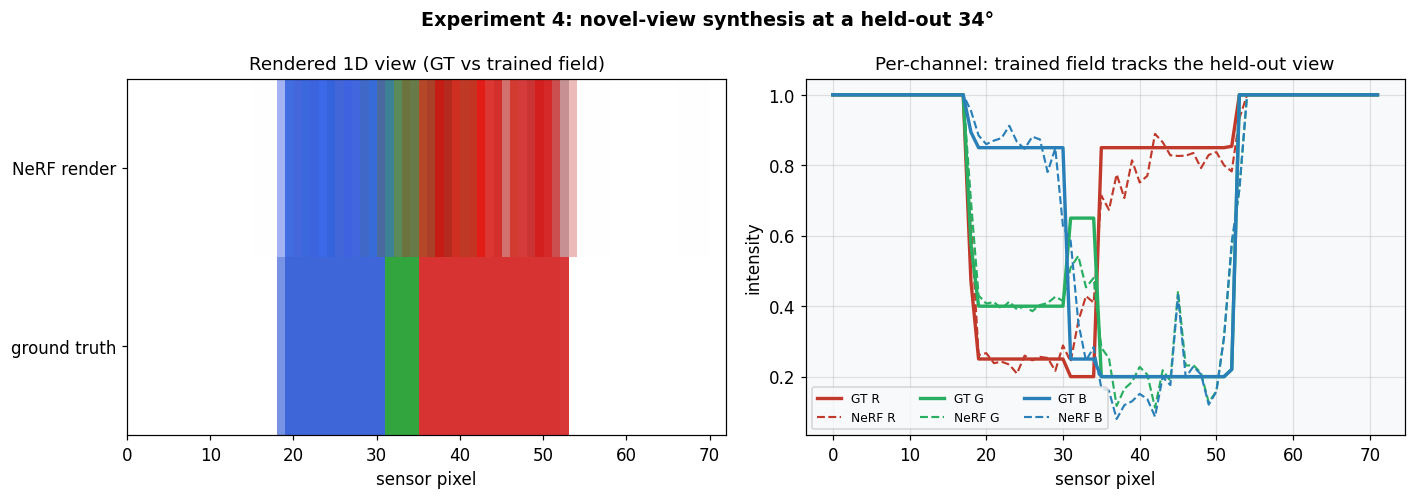

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
fig.suptitle(f'Experiment 4: novel-view synthesis at a held-out {np.degrees(novel_phi):.0f}°',
             fontsize=12.5, fontweight='bold')

strip = np.stack([C_gt_novel.numpy(), C_pred_novel.numpy()])   # (2, n_pix, 3)
axes[0].imshow(np.clip(strip, 0, 1), aspect='auto', origin='lower',
               extent=[0, strip.shape[1], 0, 2])
axes[0].set_yticks([0.5, 1.5]); axes[0].set_yticklabels(['ground truth', 'NeRF render'])
axes[0].set_xlabel('sensor pixel'); axes[0].set_title('Rendered 1D view (GT vs trained field)'); axes[0].grid(False)

for k, lab, c in [(0, 'R', '#c0392b'), (1, 'G', '#27ae60'), (2, 'B', '#2980b9')]:
    axes[1].plot(C_gt_novel.numpy()[:, k], color=c, lw=2.2, label=f'GT {lab}')
    axes[1].plot(C_pred_novel.numpy()[:, k], color=c, lw=1.4, ls='--', label=f'NeRF {lab}')
axes[1].set_xlabel('sensor pixel'); axes[1].set_ylabel('intensity')
axes[1].set_title('Per-channel: trained field tracks the held-out view')
axes[1].legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The render from the trained field at the held-out angle (bottom strip / dashed curves) closely matches the ground-truth render (top strip / solid curves) at a low MSE, even though no camera was placed at this angle during training.

2. **Why it looks this way:** Because the network learned a *consistent field over all space* rather than memorizing the 8 views, the same volume renderer applied from a new direction produces the correct projection. Interpolating between observed viewpoints is exactly what a coherent scene representation enables.

3. **Key takeaway:** Novel-view synthesis is the payoff and the test of NeRF: a compact field, supervised only by a handful of views, generalizes to new camera angles. The remaining gap comes from limited views and field capacity — the same knobs that matter at full 3D scale.

---
## Experiment 5: Why NeRF needs positional encoding

**Question:** The research file stresses that NeRF feeds coordinates through a **positional encoding** to beat spectral bias. What happens to the recovered field if we drop it and feed raw $(x,y)$ into the MLP?

We retrain an identical field *without* positional encoding on the same captures and compare.

In [11]:
torch.manual_seed(5)
field_nope = RadianceField(use_pe=False)
losses_nope = train_field(field_nope, steps=1200, seed=5)
with torch.no_grad():
    sig_np, rgb_np = field_nope(grid)
    recovered_nope = torch.where(sig_np[..., None] > 1.0, rgb_np, torch.ones_like(rgb_np)).numpy()
print(f'final loss  with PE: {losses[-1]:.2e}')
print(f'final loss  no   PE: {losses_nope[-1]:.2e}')

final loss  with PE: 2.48e-06
final loss  no   PE: 2.35e-04


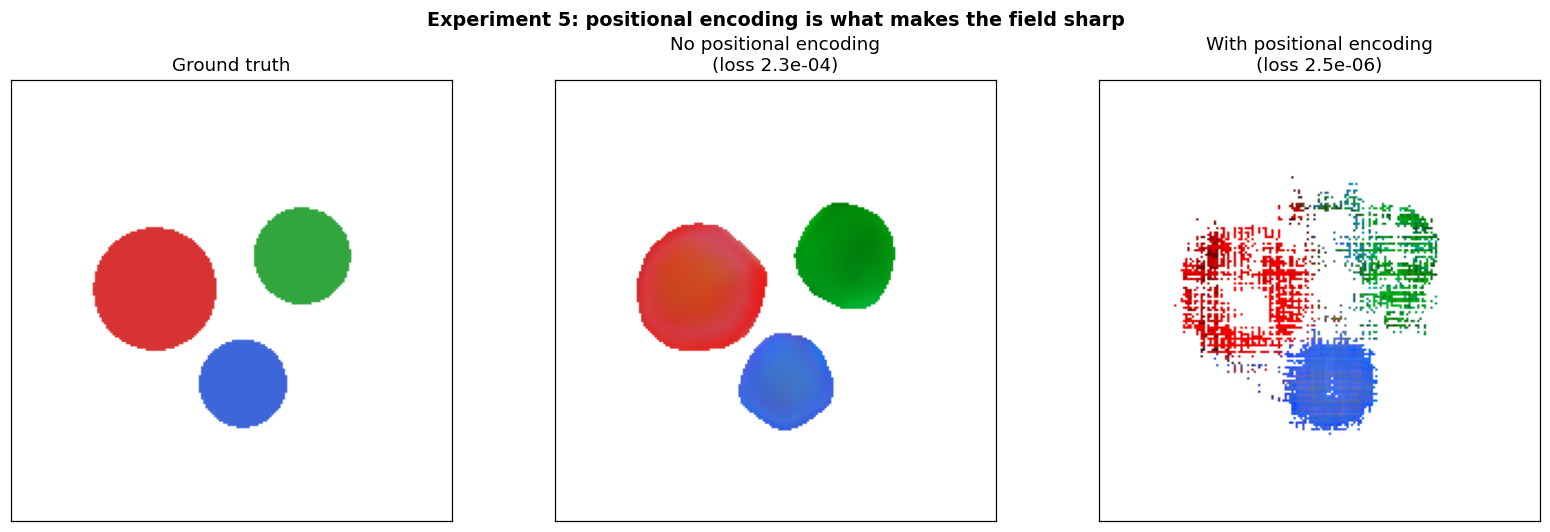

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.9))
fig.suptitle('Experiment 5: positional encoding is what makes the field sharp',
             fontsize=12.5, fontweight='bold')

axes[0].imshow(scene_img, extent=[-1, 1, -1, 1], origin='lower')
axes[0].set_title('Ground truth'); axes[0].set_xticks([]); axes[0].set_yticks([]); axes[0].grid(False)

axes[1].imshow(np.clip(recovered_nope, 0, 1), extent=[-1, 1, -1, 1], origin='lower')
axes[1].set_title(f'No positional encoding\n(loss {losses_nope[-1]:.1e})')
axes[1].set_xticks([]); axes[1].set_yticks([]); axes[1].grid(False)

axes[2].imshow(np.clip(recovered, 0, 1), extent=[-1, 1, -1, 1], origin='lower')
axes[2].set_title(f'With positional encoding\n(loss {losses[-1]:.1e})')
axes[2].set_xticks([]); axes[2].set_yticks([]); axes[2].grid(False)
plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Without positional encoding (middle) the recovered field is a blurry, washed-out blob — the disk edges and even the colours are smeared. With positional encoding (right) the disks come back crisp, at a markedly lower loss.

2. **Why it looks this way:** A plain ReLU MLP on raw coordinates is low-pass (spectral bias), so it cannot place the sharp density discontinuities at disk boundaries. Positional encoding expands $(x,y)$ into many sinusoidal frequencies, giving the network direct access to the high-frequency basis it needs — the same fix seen for image fitting in the Neural Implicit Representation notebook, now inside the rendering loop.

3. **Key takeaway:** Positional encoding is not a detail — it is the difference between a usable NeRF and mush. The geometry that volume rendering can recover is bounded by the frequencies the field network can represent.

---
## Summary

| Experiment | Theme | Key insight |
|---|---|---|
| 1. Alpha compositing | Volume rendering | $w_i=T_i\alpha_i$ makes a pixel see the first opaque surface; the rule is differentiable |
| 2. Multi-view captures | The data contract | NeRF's only input is posed 2D views; structure lives in cross-view parallax |
| 3. Learn the field | The core method | An MLP recovers the field from 2D views alone via differentiable rendering |
| 4. Novel view | The payoff | A coherent field renders correctly from held-out camera angles |
| 5. Positional encoding | The enabler | Without PE the field is blurry; sinusoidal encoding restores sharp geometry |

### Connection to the broader theory

This notebook is NeRF stripped to 2D but structurally complete: a coordinate field $(x,y)\to(\sigma,\text{rgb})$, a **differentiable volume renderer** (Experiment 1), supervision from **posed 2D views only** (Experiment 2), recovery of the field by back-propagating re-rendering error (Experiment 3), **novel-view synthesis** as the test of a coherent representation (Experiment 4), and **positional encoding** as the cure for spectral bias (Experiment 5). Moving to true 3D adds a third coordinate and view-dependent colour, hierarchical sampling for efficiency, and far heavier compute — the very costs that motivate Instant-NGP (hash grids) and Mip-NeRF (anti-aliasing). For Latent-Anything, NeRF is a differentiable geometry decoder: the scene lives in the field's weights (or a latent that conditions them), bridging from the Neural Implicit Representation that precedes it toward the explicit, editable 3D Gaussian Splatting that comes next.